### IMPORTATION DES BIBLIOTHEQUES ET PARAMETRES GLOBAUX

In [21]:
# ---  Préambule : imports ---
%matplotlib inline

import os, sys, importlib
from pathlib import Path
import ipynbname
import geopandas as gpd

# ---  Définition des chemins de base ---
base_path = Path(ipynbname.path()).parent.parent.parent  # racine du projet
path_data = base_path / 'Data'

# ---  Ajouter dossier scripts au Python path ---
scripts_path = base_path / 'Code' / 'Formatage'/'scripts'
sys.path.append(str(scripts_path.resolve()))

print("📌 **CONFIGURATION DES CHEMINS**")
print(f"📍 base_path    : {base_path}")
print(f"📂 path_data     : {path_data}")
print(f"📂 scripts_path  : {scripts_path}")


📌 **CONFIGURATION DES CHEMINS**
📍 base_path    : C:\Users\Aubin\Documents\MANTIS
📂 path_data     : C:\Users\Aubin\Documents\MANTIS\Data
📂 scripts_path  : C:\Users\Aubin\Documents\MANTIS\Code\Formatage\scripts


### CREATION DE LA GRILLE

In [37]:
# Paramètres pour l'importation des données géographiques et la création de la grille
geo_file = path_data/'SIG_global'/'world_boundaries.json'
zone="Cambodia"
name_attribute="sovereignt"
code_attribute='sov_a3'
cell_sizes_km=[100,50,20,10,5]
tolerance=0

# Créer le dossier (et les parents si nécessaire) s'il n'existe pas
output = path_data / "SIG_zone" / zone
output.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier créé ou existant : {output}")

📁 Dossier créé ou existant : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia


✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_100km.geojson
✅ Grille pour 100 km générée et enregistrée avec clé cellID_100km
✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_50km.geojson
✅ Grille pour 50 km générée et enregistrée avec clé cellID_50km
✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_20km.geojson
✅ Grille pour 20 km générée et enregistrée avec clé cellID_20km
✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_10km.geojson
✅ Grille pour 10 km générée et enregistrée avec clé cellID_10km
✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_5km.geojson
✅ Grille pour 5 km générée et enregistrée avec clé cellID_5km


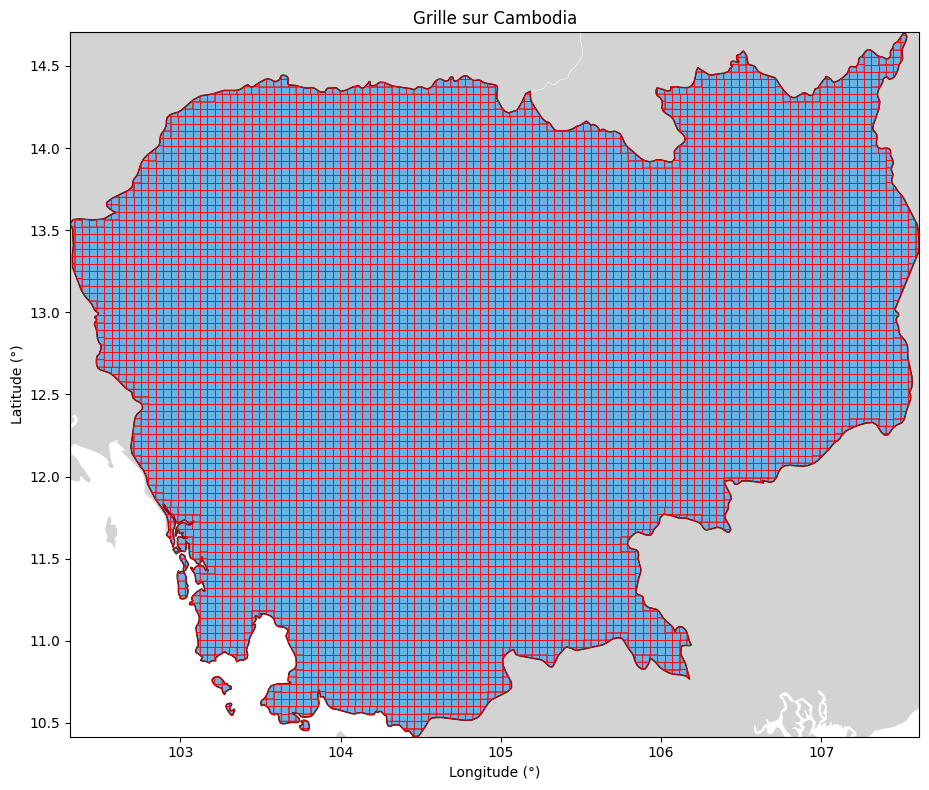

In [38]:
# Importer les fonctions
import formatage_geo
importlib.reload(formatage_geo)
from formatage_geo import generate_country_grid, plot_country_grid, simplify_world_geometry,save_country_grid

# Charger les données
geo_gdf = gpd.read_file(os.path.join(geo_file))

# Simplifier la géométrie
geo_gdf = simplify_world_geometry(geo_gdf, tolerance=tolerance)

# Générer les grilles et les sauvegarder
for cell_size_km in cell_sizes_km:
    cle_geo = f'cellID_{cell_size_km}km'
    grid = generate_country_grid(
        world_gdf=geo_gdf,
        country_name=zone,
        name_attribute=name_attribute,
        grid_size_km=cell_size_km,
        cle_geo=cle_geo,
        code_attribute=code_attribute
    )
    save_country_grid(grid, output, zone, cle_geo)
    print(f"✅ Grille pour {cell_size_km} km générée et enregistrée avec clé {cle_geo}")

# Afficher la dernière grille générée
plot_country_grid(geo_gdf, grid, name_attribute, zone)


### TRAITEMENT DES DONNEES BIODIV

In [39]:
# Paramètres pour l'importation et le nettoyage des données biodiversité
source = 'GBIF'                   # 'GBIF' or 'INPN'
zone = 'Cambodia'
cle_ID = "speciesID"              # Colonne identifiant les espèces
annee_min = 1950                  # Année minimale à conserver
chunksize = 10_000_000            # Taille des chunks pour la lecture

# Créer le dossier (et les parents si nécessaire) s'il n'existe pas
output = path_data / source / 'cleaned' / zone
output.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier créé ou existant : {output}")


📁 Dossier créé ou existant : C:\Users\Aubin\Documents\MANTIS\Data\GBIF\cleaned\Cambodia


In [48]:
# Importer les fonctions
import formatage_biodiv
import importlib
importlib.reload(formatage_biodiv)
from formatage_biodiv import read_biodiv_chunks, save_clean_biodiv, inspect_columns_with_examples

# Définir le chemin du fichier source
path_fichier = path_data / source / 'raw' / f"{source}_{zone}.csv"

# Lire et nettoyer les données
print(f"📥 Lecture et nettoyage des données {source} pour {zone}...")

df_biodiv_clean = read_biodiv_chunks(
    path_fichier=path_fichier,
    source=source,
    cle_ID=cle_ID,
    annee_min=annee_min,
    chunksize=chunksize
)

# Sauvegarder les données nettoyées
print(f"💾 Sauvegarde des données nettoyées pour {zone}...")
save_clean_biodiv(df_biodiv_clean, source, zone, path_data)

# Afficher un aperçu des données nettoyées
print("\n📊 Informations sur les données nettoyées :")
print(df_biodiv_clean.info())

print("\n🖐 Quelques lignes d'exemple :")
display(df_biodiv_clean.head())

📥 Lecture et nettoyage des données GBIF pour Cambodia...
✅ Séparateur choisi : '	' avec 50 colonnes

--- Traitement chunk 1 ---
🧾 Colonnes présentes : ['kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'taxonRank', 'occurrenceStatus', 'nombreObs', 'lat', 'lon', 'eventDate', 'month', 'year', 'speciesID']
   🔧 Dates (année + mois valides)   -27135 lignes (2.27%)
   🔧 Coordonnées valides            -24372 lignes (2.09%)
   🔧 occurrenceStatus=PRESENT       -70 lignes (0.01%)
   🔧 Année >= 1950                  -1438 lignes (0.13%)
   🔧 taxonRank=SPECIES|VARIETY      -51830 lignes (4.54%)
✅ Chunk 1 traité. Total lignes cumulées : 1089061

🎉 Lecture complète terminée : 1089061 lignes
💾 Sauvegarde des données nettoyées pour Cambodia...
🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\GBIF\clean\GBIF_Cambodia.csv

📊 Informations sur les données nettoyées :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089061 entries, 0 to 1089060
Data columns (total 1

,kingdom,phylum,order,family,genus,species,nombreObs,lat,lon,month,year,speciesID
0,Plantae,Tracheophyta,Malpighiales,Euphorbiaceae,Croton,Croton caudatus,1.0,12.60000,104.91000,2,2009,3057531
1,Plantae,Tracheophyta,Fabales,Fabaceae,Tephrosia,Tephrosia purpurea,1.0,11.47667,104.59389,9,2005,5342239
2,Plantae,Tracheophyta,Fabales,Fabaceae,Aeschynomene,Aeschynomene aspera,1.0,10.58306,104.25667,9,2005,2949102
3,Plantae,Tracheophyta,Fabales,Fabaceae,Aeschynomene,Aeschynomene indica,1.0,11.47639,104.89333,9,2005,2949250
4,Plantae,Tracheophyta,Fabales,Fabaceae,Grona,Grona heterophylla,1.0,10.58306,104.25667,9,2005,10734509


### Obs to Grid

In [51]:
#Parameters
cell_size_km=5
cle_geo = f'cellID_{cell_size_km}km'

file_path_biodiv = path_data / source / 'clean' / f"{source}_{zone}.csv"

file_path_grid= path_data / 'SIG_zone' / zone / f"{zone}_{cle_geo}.geojson"

In [55]:
# Importer les fonctions
import formatage_ObsToGrid
importlib.reload(formatage_ObsToGrid)
from formatage_ObsToGrid import assign_grid_to_points,generate_taxo_dict,aggregate_by_grid_species, save_processed_biodiv

# Importation des données 
print(f"📥 Lecture du fichier nettoyé : {file_path_biodiv}")
df_biodiv_clean = pd.read_csv(file_path_biodiv,dtype={cle_ID: "string"})

print(f"📥 Lecture du fichier grille : {file_path_grid}")
grid = gpd.read_file(os.path.join(file_path_grid))

# Assigner la grille
df_with_grid = assign_grid_to_points(df_biodiv_clean, grid, cle_geo)

# Ajouter les noms vernaculaires
dico_noms_vernaculaires = pd.read_csv(path_data/"Taxonomie"/ "dico_noms_vernaculaires_merged.csv")

# Chargement des noms vernaculaires
df_with_grid = pd.merge(df_with_grid, dico_noms_vernaculaires, on=cle_ID, how="left")

# Générer le dictionnaire taxonomique
dico_taxo = generate_taxo_dict(df_with_grid, cle_ID=cle_ID)

# Agréger et fusionner avec le dictionnaire taxonomique
df_final = aggregate_by_grid_species(df_with_grid, cle_geo, dico_taxo, cle_ID=cle_ID)

# Sauvegarder le dataframe
save_processed_biodiv(df_final, source, zone, cle_geo,path_data)


📥 Lecture du fichier nettoyé : C:\Users\Aubin\Documents\MANTIS\Data\GBIF\clean\GBIF_Cambodia.csv
📥 Lecture du fichier grille : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Cambodia\Cambodia_cellID_5km.geojson
⏱ Temps estimé pour l'ensemble des points : 4.53 s (basé sur 10890 points)
✅ Temps réel pour l'opération complète : 2.83 s
➡️ 1063607 points avec plusieurs cellules correspondantes
➡️ 10414 points sans cellule correspondante
🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\GBIF\processed\GBIF_Cambodia_cellID_5km.csv


WindowsPath('C:/Users/Aubin/Documents/MANTIS/Data/GBIF/processed/GBIF_Cambodia_cellID_5km.csv')

### Fusion

In [ ]:
# Parameters
seuil_obs=1000

C:\Users\Aubin\Documents\MANTIS\Code\Formatage\scripts\formatage_fusion.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


🔄 Fusion des cellules en cours...
6870 cellules restantes (90.0%), min nombreObs = 0.0
6183 cellules restantes (81.0%), min nombreObs = 0.0
5564 cellules restantes (72.9%), min nombreObs = 0.0
5007 cellules restantes (65.6%), min nombreObs = 0.0
4506 cellules restantes (59.0%), min nombreObs = 0.0
4055 cellules restantes (53.1%), min nombreObs = 0.0
3649 cellules restantes (47.8%), min nombreObs = 0.0
3284 cellules restantes (43.0%), min nombreObs = 0.0
2955 cellules restantes (38.7%), min nombreObs = 1.0
2659 cellules restantes (34.8%), min nombreObs = 1.0
2393 cellules restantes (31.3%), min nombreObs = 2.0
2153 cellules restantes (28.2%), min nombreObs = 4.0
1937 cellules restantes (25.4%), min nombreObs = 8.0
1743 cellules restantes (22.8%), min nombreObs = 14.0
1568 cellules restantes (20.5%), min nombreObs = 24.0
1411 cellules restantes (18.5%), min nombreObs = 36.0
1269 cellules restantes (16.6%), min nombreObs = 54.0
1142 cellules restantes (15.0%), min nombreObs = 77.0
1027 ce

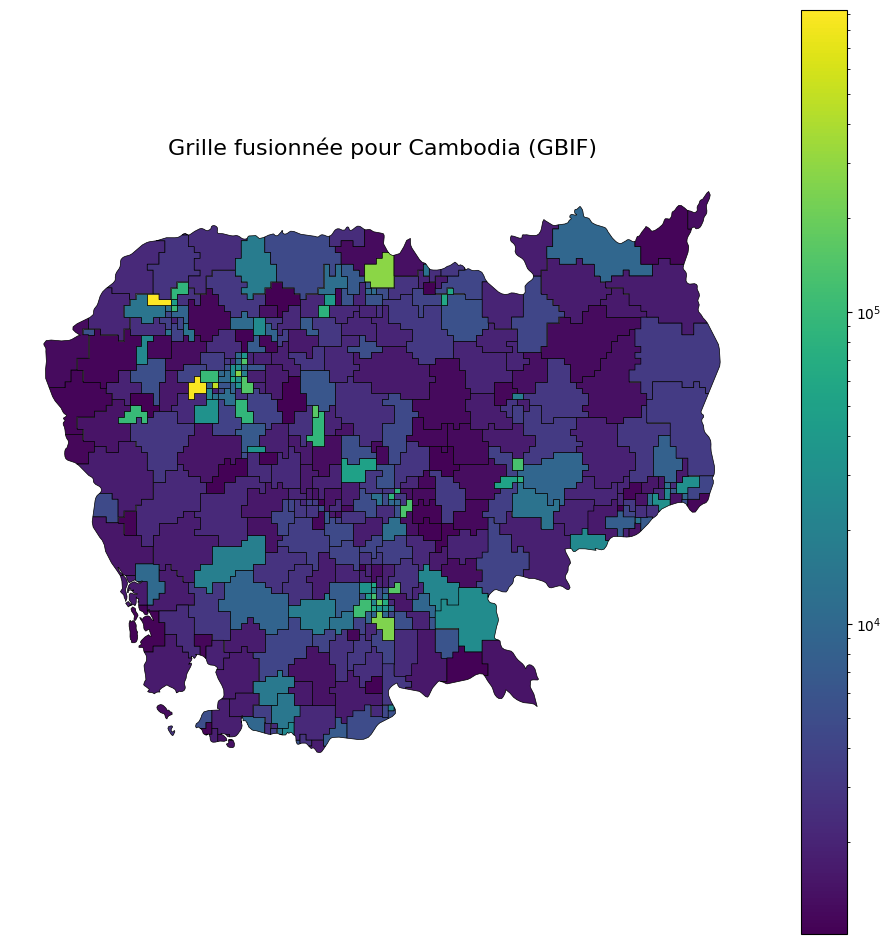

🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\GBIF\processed\GBIF_Cambodia_cellID_5km_fusionned1000.csv


WindowsPath('C:/Users/Aubin/Documents/MANTIS/Data/GBIF/processed/GBIF_Cambodia_cellID_5km_fusionned1000.csv')

In [56]:
import formatage_fusion
importlib.reload(formatage_fusion)
from formatage_fusion import fusion_cells_by_obs,apply_fusion_to_biodiv,plot_fusionned_grid,save_fusionned_biodiv

# Fusion des cellules avec seuil 1000 observations
merged_fusion = fusion_cells_by_obs(df_final, grid, cle_geo, var_obs='nombreObs', seuil=seuil_obs)

# gdf_fusion est votre GeoDataFrame résultant de fusion_cells_by_obs
plot_fusionned_grid(merged_fusion, var_obs='nombreObs', title=f"Grille fusionnée pour {zone} ({source})", figsize=(12,12),log_scale=True)

# Appliquer les fusions sur le dataframe original et sauvegarder
df_biodiv_fusion = apply_fusion_to_biodiv(df_final, merged_fusion, cle_geo=cle_geo, cle_ID='speciesID', var_obs='nombreObs')

save_fusionned_biodiv(df_biodiv_fusion, source, zone, cle_geo, path_data,seuil_obs)
